# Mathematical Tools
Finance has evolved into a discipline of applied mathematics. It used to be the case that research papers in finance would be full of text and have little mathematical expresssions and equations, but now research papers are predominately math with a contextual text wrapped around it. This makes the Jupyter Notebook a great tool for conducting research. In this chapter, we'll look at how python handles the following:
- Approximation
- Convex Optimization
- Integration
- Symbolic Computation

In [1]:
%%html
<style>
table {float:left}
</style>

## Approximation
Using the familiar python libraries, I'll instantiate an example function that will be used across multiple examples in the chapter. The main focus is approximation of this function over a given interval by *regression* and *interpolation* techniques. First, I'll plot the function over the interval: $[-2\pi, 2\pi]$. 

In [2]:
import numpy as np
from pylab import plt, mpl
plt.style.use('seaborn')
mpl.rcParams['font.family'] = 'serif'
%matplotlib inline

In [3]:
def f(x):
    return np.sin(x) + 0.5 * x

In [4]:
def create_plot(x, y, styles, labels, axlabels):
    plt.figure(figsize=(10,6))
    for i in range(len(x)):
        plt.plot(x[i], y[i], styles[i], label=labels[i])
        plt.xlabel(axlabels[0])
        plt.ylabel(axlabels[1])
    plt.legend(loc=0)

In [5]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 50)

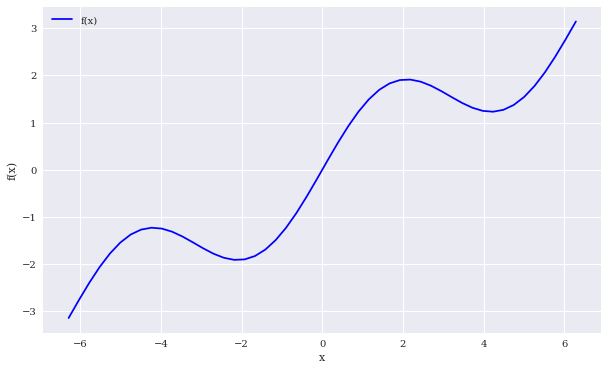

In [6]:
create_plot([x], [f(x)], ['b'], ['f(x)'], ['x', 'f(x)'])

## Regression
Regression works well for approximating one-dimensional functions and can also be applied for higher dimensional analysis. A regression task takes in a set of basis functions $b_d, d \in \{1,\ldots,D\}$ and finds the optimal parameters $\alpha_1^\star,\ldots,\alpha_D^\star$ according to Equation 11-1, where $y_i \equiv f(x_i)$ for $i \in \{1,\ldots,I\}$ observation points. The $x_i$ are considered *independent* observations and the $y_i$ *dependent* observations.

*Equation 11-1. Minimization problem of regression*

$
\begin{equation*}
\begin{aligned}
& \underset{\alpha_1,\ldots,\alpha_D}{\text{min}}\frac{1}{I}\sum^{I}_{i=1} (y_i - \sum^{D}_{d=1} \alpha_d * b_d (x_i))^2
\end{aligned}
\end{equation*}
$

In layman's terms, regression can be thought of as a method to identify what variables are most important for making some prediction

### Monomials as basis functions
One of the simplest cases is to take monomials as basis functions-i.e., $b_1=1, b_2=x, b_3=x^2, b_4=x^3, \ldots$. In such a case, NumPy has built-in functions for both the determination of the optimal parameters (np.polyfit()) and the evaluation of the approximation given a set of input values (np.polyval()).

Table 11-1 lists the parameters the np.polyfit() function takes. Given the returned optimal regression coefficients p from np.polyfit(), np.polyval(p, x) then returns the regression values for the x coordinates.

*Table 11-1. Parameters of polyfit() function*

| Parameter   | Description |
| ----------- | ----------- |
| x           | *x* coordinates (independent variable values)|
| y           | *y* coordinates (dependent variable values)|
| deg         | Degree of the fitting polynomial|
| full        | If True, returns diagnostic information in addition|
| w           | Weights to apply to the *y* coordinates|
| cov         | If True, returns covariance matrix in addition|


We can compare the regression result with the original function that was presented. Keep in mind, a linear regression cannot account for the sin part of the example function.

In [7]:
# apply linear regression
res = np.polyfit(x, f(x), deg=1, full=True)

In [8]:
# show full results, including regression parameters, residuals, effective rank, singular values, and relative condition number
res

(array([ 4.28841952e-01, -4.31775426e-17]),
 array([21.03238686]),
 2,
 array([1., 1.]),
 1.1102230246251565e-14)

In [9]:
# evaluation using regression parameters
ry = np.polyval(res[0], x)

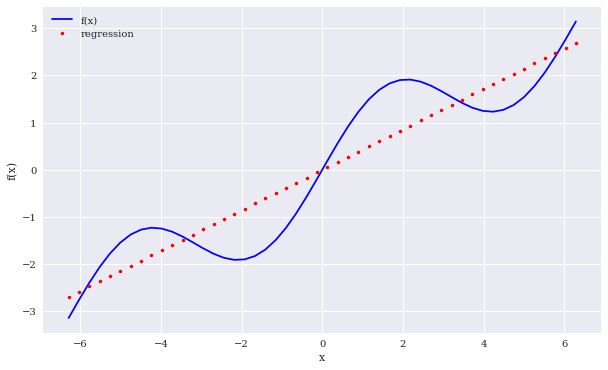

In [10]:
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])

To account for the sin part of the function, higher-order monomials are going to be necessary. Below, the regression will attempt to take monomials up to the order of 5 as basis functions.

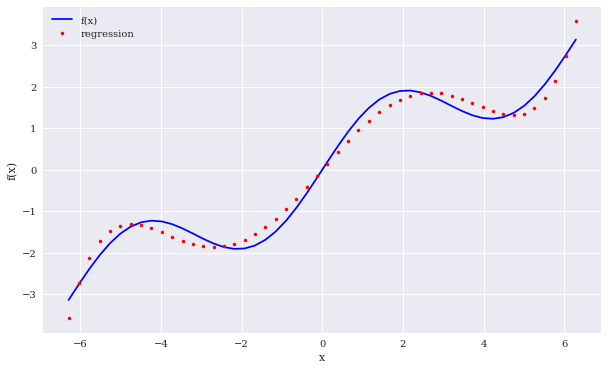

In [11]:
reg = np.polyfit(x, f(x), deg=5)
ry = np.polyval(reg, x)

create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])

Now I'll take the the monomials up to order 7 to approximate the example function. This is pretty convincing.

In [12]:
reg = np.polyfit(x, f(x), 7)
ry = np.polyval(reg, x)

In [13]:
# check if the function and regression values are the same (or at least close)
np.allclose(f(x), ry)

False

In [14]:
# Calculate mean squared error for the regression values given the function values
np.mean((f(x) - ry) ** 2)

0.0017769134759517671

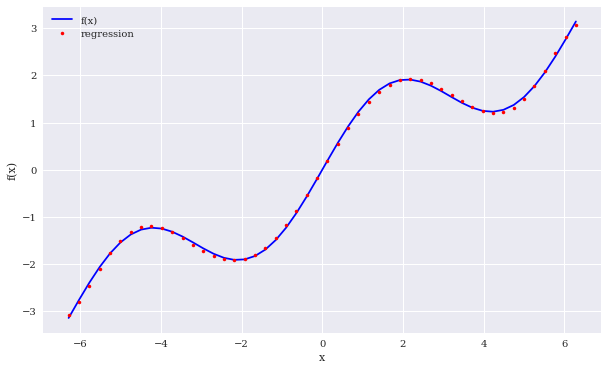

In [15]:
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])

## Individual Basis Functions
In general, better regression results can be reached by choosing better sets of basis functions. You want to exploit knowlege about the function to approximate. Here, the individual basis functions have to be defined via a matrix approach (like a NumPy ndarray object). First, the case with monomials up to order 3. The central function here is np.linalg.lstsq():

In [16]:
matrix = np.zeros((3+1, len(x)))
matrix[3, :] = x ** 3
matrix[2, :] = x ** 2
matrix[1, :] = x
matrix[0, :] = 1

In [17]:
reg = np.linalg.lstsq(matrix.T, f(x), rcond=None)[0]

In [18]:
reg.round(4)

array([ 0.    ,  0.5628, -0.    , -0.0054])

In [19]:
ry = np.dot(reg, matrix)

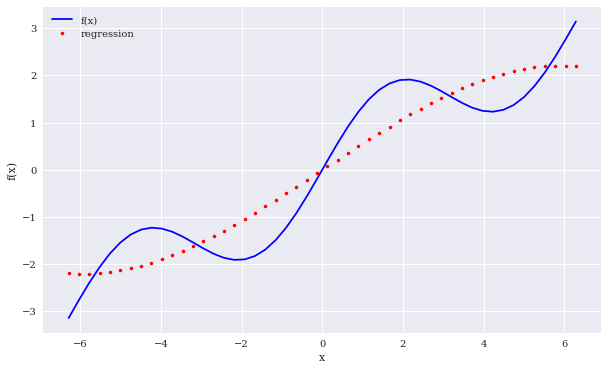

In [20]:
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])

The result here is not as good as we expected based on the previous examples with monomials. Using this general approach will allow us to explout knowledge about the example function though. Specifically we are talking about the sin part of the function. We can include a sine function in the set of basis functions, replacing the highest order monomial will show a perfect fit. 

In [21]:
matrix[3, :] = np.sin(x)

In [22]:
reg = np.linalg.lstsq(matrix.T, f(x), rcond=None)[0]

In [23]:
reg.round(4)

array([0. , 0.5, 0. , 1. ])

In [24]:
ry = np.dot(reg, matrix)

In [25]:
np.allclose(f(x), ry)

True

In [26]:
np.mean((f(x) - ry) ** 2)

9.145856119906106e-31

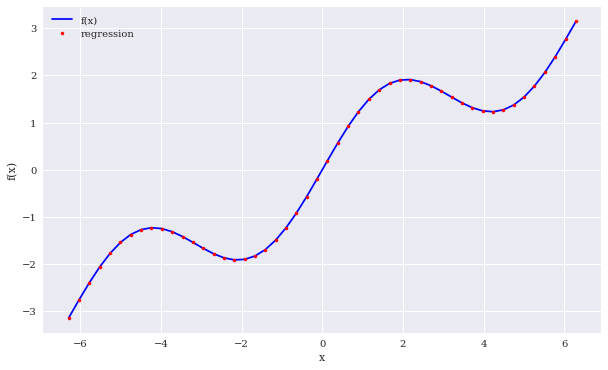

In [27]:
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])

## Noisy Data
Regression can cope equally well with *noisy* data, which can come as the result of data from a simulation or from imperfect measurements. To illustrate, independent observations with noise and dependent observations with noise are generated. The figure will reveal that the regression results are closer to the original function than the noisy data points. In a sense, the regression averages out the noise to some extent.

In [28]:
xn = np.linspace(-2 * np.pi, 2 * np.pi, 50)
xn = xn + 0.15 * np.random.standard_normal(len(xn))
yn = f(xn) + 0.25 * np.random.standard_normal(len(xn))

In [29]:
reg = np.polyfit(xn, yn, 7)
ry = np.polyval(reg, xn)

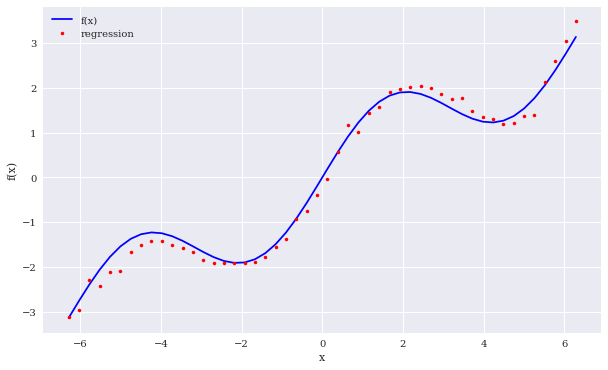

In [30]:
create_plot([x, x], [f(x), ry], ['b', 'r.'], ['f(x)', 'regression'], ['x', 'f(x)'])

## Unsorted Data
Regression can also be applied to unsorted data. The previous examples all rely on sorted *x* data. This does not have to be the case. To make the point, let's look at another randomization approach for the *x* values. In this case, one can hardly identify any structure by just visually inspecting the raw data.

In [31]:
xu = np.random.rand(50) * 4 * np.pi - 2 * np.pi
yu = f(xu)

In [32]:
print(xu[:10].round(2))
print(yu[:10].round(2))

[-0.83 -1.65  3.1   3.49  3.67 -4.05 -0.18  1.96 -0.96  5.  ]
[-1.16 -1.82  1.59  1.4   1.33 -1.24 -0.27  1.9  -1.3   1.54]


In [33]:
reg = np.polyfit(xu, yu, 5)
ry = np.polyval(reg, xu)

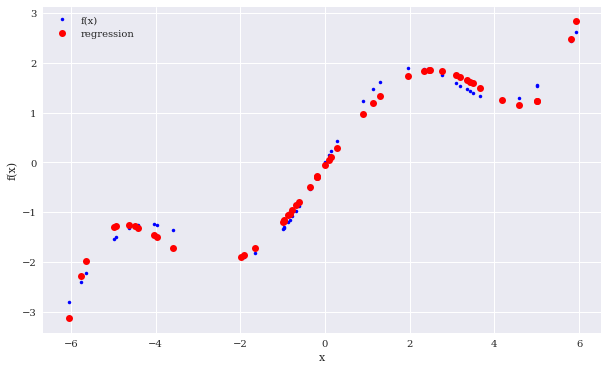

In [34]:
create_plot([xu, xu], [yu, ry], ['b.', 'ro'], ['f(x)', 'regression'], ['x', 'f(x)'])

## Multiple Dimensions
Another convenient characteristic of the least-squares regression approach is that it carries over to multiple dimensions without too many modifications. As an example function take fm(), as presented next:

In [35]:
def fm(p):
    x, y = p
    return np.sin(x) + 0.25 * x + np.sqrt(y) + 0.05 * y ** 2

To visualize this, grids of independent data points are needed. Based on such 2D grids of independent and resulting dependent data points, embodied in the following by X, Y, and Z, the next figure will present the shape of the function fm():

In [36]:
x = np.linspace(0, 10, 20)
y = np.linspace(0, 10, 20)
X, Y = np.meshgrid(x, y)

In [37]:
Z = fm((X, Y))
x = X.flatten()
y = Y.flatten()

In [38]:
from mpl_toolkits.mplot3d import Axes3D

Text(0.5, 0, 'f(x, y)')

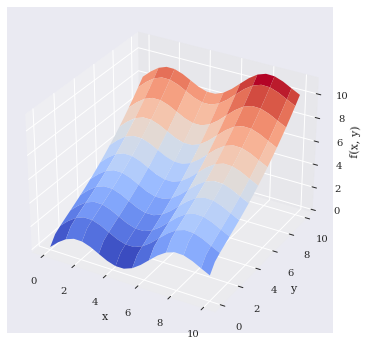

In [39]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(X, Y, Z, rstride=2, cstride=2, cmap='coolwarm', linewidth=0.5, antialiased=True)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')

Good regression results rely on basis functions that are implemented. We can show the perfect regression results by factoring in knowledge about the function fm() itself, both an np.sin() and an np.sqrt() are included.

In [40]:
matrix = np.zeros((len(x), 6+1))
matrix[:, 6] = np.sqrt(y)
matrix[:, 5] = np.sin(x)
matrix[:, 4] = y ** 2
matrix[:, 3] = x ** 2
matrix[:, 2] = y
matrix[:, 1] = x
matrix[:, 0] = 1

In [41]:
reg = np.linalg.lstsq(matrix, fm((x, y)), rcond=None)[0]

In [42]:
RZ = np.dot(matrix, reg).reshape((20, 20))

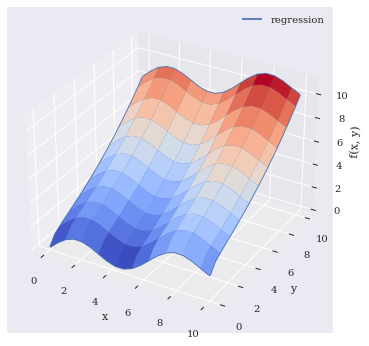

In [43]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
surf1 = ax.plot_surface(X, Y, Z, rstride=2, cstride=2, cmap=mpl.cm.coolwarm, linewidth=0.5, antialiased=True)
surf2 = ax.plot_wireframe(X, Y, RZ, rstride=2, cstride=2, label='regression')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.legend()

### Regression
Least-squares regression approaches have multiple areas of application, including simple function approximation and function approximation based on noisy or unsorted data. These can be applied at different dimensions and for different purposes, because the underlying math keeps the prediction consistent. Again, basis functions are important when considering the presentation of a data set.

## Interpolation
Interpolation is a statistical method by which related known values are used to estimate an unknown price or potential yield of a security. Interpolation is achieved by using other established values that are located in sequence with the unknown value. Compared with regression, interpolation (e.g., with cubic splines) is more involved mathematically. It is also limited to low-dimensional problems. Given an ordered set of observation points (ordered in the x dimension), the basic idea is to do a regression between two neighboring data points in such a way that not only are the data points perfectly matched by the resulting piecewise-defined interpolation function, but also the function is continuously differentiable at the data points. Continuous differentiability requires at least interpolation of degree 3 -- i.e., with cubic splines. However, the approach also works in general with quadratic and even linear splines. The following will implement a linear splines interpolation.

In [44]:
import scipy.interpolate as spi

In [45]:
x = np.linspace(-2 * np.pi, 2 * np.pi, 25)

In [46]:
def f(x):
    return np.sin(x) + 0.5 * x

In [47]:
ipo = spi.splrep(x, f(x), k=1)

In [48]:
iy = spi.splev(x, ipo)

In [49]:
np.allclose(f(x), iy)

True

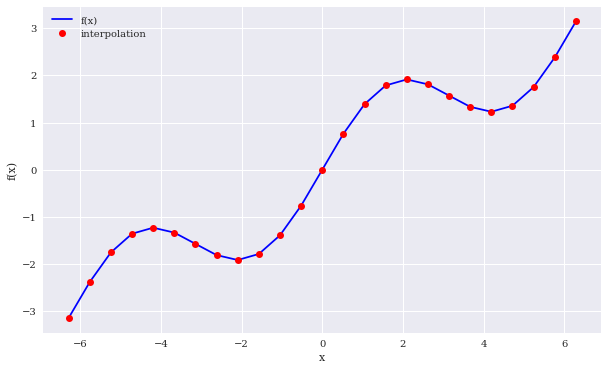

In [50]:
create_plot([x, x], [f(x), iy], ['b', 'ro'], ['f(x)', 'interpolation'], ['x', 'f(x)'])

The application itself, given an x-ordered set of data points, is as simple as the application of np.polyfit() and np.polyval(). Here, the respective functions are sci.splrep() and sci.splev(). This function can take the following parameters:

*Table 11-2. Parameters of splrep() function*

| Parameter   | Description |
| ----------- | ----------- |
| x           | (Ordered) x coordinates (independent variable values)|
| y           | (x-Ordered) y coordinates (dependent variable values)|
| w           | Weights to apply to the y coordinates|
| xb, xe      | Interval to fit: if None then [x[0], x[-1]]|
| k           | Order of the spline fit(1 <= k <= 5)|
| s           | Smoothing factor (the larger, the more smoothing)|
| full_ouput  | If True, returns additional output|
| quiet       | If True, suppresses messages|



*Table 11-3. Parameters of splev() function*

| Parameter   | Description |
| ----------- | ----------- |
| x           | (Ordered) x coordinates (independent variable values)|
| tck         | Sequence of length 3 returned by splrep()(knots, coefficients, degree)|
| der         | Order of derivative (0 for function, 1 for first derivative)|
| ext         | Behavior if x not in knot sequence(0 = extrapolate, 1 = return 0,2 = raise ValueError)|

Spline interpolation is typically used to generate estimates for dependent values of independent data points not included in the original observations. To this end, the next example picks a much smaller interval and has a closer look at the interpolated values with the linear splines. For certain applications this might not be precise enough. In addition, it is evident that the function is not continuously differentiable at the original data points - another drawback.

In [51]:
xd = np.linspace(1.0, 3.0, 50)
iyd = spi.splev(xd, ipo)

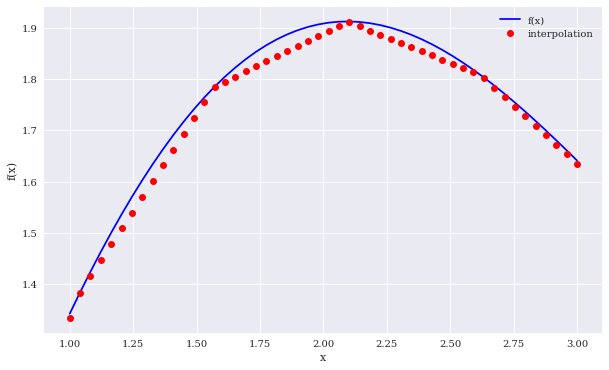

In [52]:
create_plot([xd, xd], [f(xd), iyd], ['b', 'ro'], ['f(x)', 'interpolation'], ['x', 'f(x)'])

Now we'll use cubic splines, which you will notice considerably improves the results seen in the graph before.

In [53]:
ipo = spi.splrep(x, f(x), k=3)
iyd = spi.splev(xd, ipo)

In [54]:
np.allclose(f(xd), iyd)

False

In [55]:
np.mean((f(xd) - iyd) ** 2)

1.1349319851436892e-08

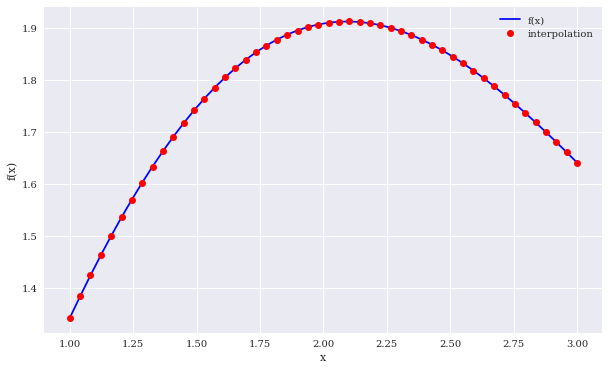

In [56]:
create_plot([xd, xd], [f(xd), iyd], ['b', 'ro'], ['f(x)', 'interpolation'], ['x', 'f(x)'])

### Interpolation
In those cases where spline interpolation can be applied, one can expect better approximation results compared to a least-squares regression approach. However, remember that sorted (and "non-noisy") data is required and that the approach is limited to low-dimensional problems. It is also computationally more demanding and might therefore take (much) longer than regression in certain use cases.

## Convex Optimization
In finance and economics, *convex optimization* plays an important role. Examples are the calibration of option pricing models to market data or the optimization of an agent's utility function. As an example, take the function fm():

In [57]:
def fm(p):
    x, y = p
    return (np.sin(x) + 0.05 * x ** 2 + np.sin(y) + 0.05 * y ** 2)

The figure below will show the function graphically for the defined intervals for x and y. This function clearly has local minima and the existence of a global minimum seems to exist, but cannot be confirmed by this represention alone.

In [58]:
x = np.linspace(-10, 10, 50)
y = np.linspace(-10, 10, 50)
X, Y = np.meshgrid(x, y)
Z = fm((X, Y))

Text(0.5, 0, 'f(x, y)')

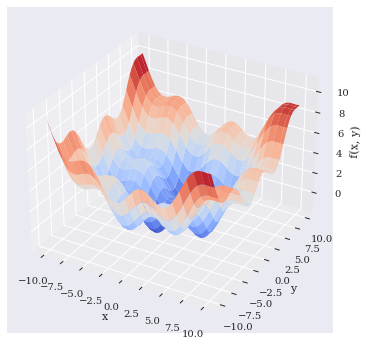

In [59]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(projection='3d')
surf = ax.plot_surface(X, Y, Z, rstride=2, cstride=2, cmap='coolwarm', linewidth=0.5, antialiased=True)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')

## Global Optimization
In what follows, both a global minimization approach and a local one are implemented. The functions sco.brute() and sco.fmin() that are applied are from scipy.optimize. To have a closer look behind the scenes during minimization procedures, the following code amends the original function by an option to output current parameter values as well as the function value. This allows us to keep track of all relevant information for the procedure.

In [60]:
import scipy.optimize as sco

In [61]:
def fo(p):
    x, y = p
    z = np.sin(x) + 0.05 * x ** 2 + np.sin(y) + 0.05 * y ** 2
    if output == True:
        print('%8.4f | %8.4f | %8.4f' % (x, y, z))
    return z

In [62]:
output = True
sco.brute(fo, ((-10, 10.1, 5), (-10, 10.1, 5)), finish=None)

-10.0000 | -10.0000 |  11.0880
-10.0000 |  -5.0000 |   7.7529
-10.0000 |   0.0000 |   5.5440
-10.0000 |   5.0000 |   5.8351
-10.0000 |  10.0000 |  10.0000
 -5.0000 | -10.0000 |   7.7529
 -5.0000 |  -5.0000 |   4.4178
 -5.0000 |   0.0000 |   2.2089
 -5.0000 |   5.0000 |   2.5000
 -5.0000 |  10.0000 |   6.6649
  0.0000 | -10.0000 |   5.5440
  0.0000 |  -5.0000 |   2.2089
  0.0000 |   0.0000 |   0.0000
  0.0000 |   5.0000 |   0.2911
  0.0000 |  10.0000 |   4.4560
  5.0000 | -10.0000 |   5.8351
  5.0000 |  -5.0000 |   2.5000
  5.0000 |   0.0000 |   0.2911
  5.0000 |   5.0000 |   0.5822
  5.0000 |  10.0000 |   4.7471
 10.0000 | -10.0000 |  10.0000
 10.0000 |  -5.0000 |   6.6649
 10.0000 |   0.0000 |   4.4560
 10.0000 |   5.0000 |   4.7471
 10.0000 |  10.0000 |   8.9120


array([0., 0.])

In [63]:
output = False
opt1 = sco.brute(fo, ((-10, 10.1, 0.1), (-10, 10.1, 0.1)), finish=None)

In [64]:
opt1

array([-1.4, -1.4])

In [65]:
fm(opt1)

-1.7748994599769203

The optimal parameter values are now x = y = -1.4 and the minimal function value for the global minimization is about -1.7749.

## Local Optimization
The local convex optimization that follows draws on the results from the global optimization. The function sco.fmin() takes as input the function to minimize and the starting parameter values. Optional parameter values are the input parameter tolerance and function value tolerance, as well as the maximum number of iterations and function calls. The local optimization further improves the result: 

In [66]:
output = True
opt2 = sco.fmin(fo, opt1, xtol=0.001, ftol=0.001, maxiter=15, maxfun=20)

 -1.4000 |  -1.4000 |  -1.7749
 -1.4700 |  -1.4000 |  -1.7743
 -1.4000 |  -1.4700 |  -1.7743
 -1.3300 |  -1.4700 |  -1.7696
 -1.4350 |  -1.4175 |  -1.7756
 -1.4350 |  -1.3475 |  -1.7722
 -1.4088 |  -1.4394 |  -1.7755
 -1.4438 |  -1.4569 |  -1.7751
 -1.4328 |  -1.4427 |  -1.7756
 -1.4591 |  -1.4208 |  -1.7752
 -1.4213 |  -1.4347 |  -1.7757
 -1.4235 |  -1.4096 |  -1.7755
 -1.4305 |  -1.4344 |  -1.7757
 -1.4168 |  -1.4516 |  -1.7753
 -1.4305 |  -1.4260 |  -1.7757
 -1.4396 |  -1.4257 |  -1.7756
 -1.4259 |  -1.4325 |  -1.7757
 -1.4259 |  -1.4241 |  -1.7757
 -1.4304 |  -1.4177 |  -1.7757
 -1.4270 |  -1.4288 |  -1.7757


In [67]:
opt2

array([-1.42702972, -1.42876755])

In [68]:
fm(opt2)

-1.7757246992239009

For many convex optimization problems it is advisable to have a global minimization before the local one. The major reason for this is that local convex optimization algorithms can easily be trapped in a local minimum (or do "basin hopping"), ignoring completely better local minima and/or a global minimum. The following shows that setting the starting parameterization to x = y = 2 gives, for example, a "minimum" value of above zero:

In [69]:
output = False
sco.fmin(fo, (2.0, 2.0), maxiter=250)

Optimization terminated successfully.
         Current function value: 0.015826
         Iterations: 46
         Function evaluations: 86


array([4.2710728 , 4.27106945])

## Constrained Optimization
So far, this section only considers unconstrained optimization problems. However, large classes of economic or financial optimization problems are constrained by one or multiple constraints. Such constraints can formally take on the form of equalities or inequalities.

As a simple example, consider the utility maximization problem of an (expected utility maximizing) investor who can invest in two risky securities. Both securities cost $q_a = q_b = 10$ USD today. After one year, they have a payoff of 15 USD and 5 USD, respectively, in state *u*, and of 5 USD and 12 USD, respectively, in state *d*. Both states are equally likely. Denote the vector payoffs for the two securities by $r_a$ and $r_b$, respectively.

The investor has a budget of $w_0 =$ 100 USD to invest and derives utility from future wealth according to the utility function $u(w) = \sqrt w$, where $w$ is the wealth (USD amount) available. Equation 11-2 is a formulation of the maximization problem where *a, b* are the numbers of securities bought by the investor.

*Equation 11-2. Expected utility maximization problem (1)*

$
\begin{equation*}
\begin{aligned}
& \underset{a,b}{\text{max}}E(u(w_1)) = p \sqrt w_{1u} + (1 - p) \sqrt w_{1d}
\end{aligned}
\end{equation*}
$

$w_1 = a * r_a + b * r_b$

$w_0 \geqslant a*q_a + b*q_b$

$a,b \geqslant 0$

Putting in all numberical assumptions, one gets the problem in Equation 11-3. Note the change to the minimization of the negative expected utility.

*Equation 11-3. Expected utility maximization problem (2)*

$
\begin{equation*}
\begin{aligned}
& \underset{a,b}{\text{max}}E(u(w_1)) = -(0.5 * \sqrt w_{1u} + 0.5 * \sqrt w_{1d})
\end{aligned}
\end{equation*}
$

$w_{1u} = a * 15 + b * 5$

$w_{1d} = a * 5 + b * 12$

$100 \geqslant a * 10 + b * 10$

$a,b \geqslant 0$


To solve this problem, the scipy.optimize.minimize() function is appropriate. This function takes as input - in addition to the function to be minimized - conditions in the form of equalities and inequalities (as a list of dict objects) as well as boundaries for the parameters (as a tuple of tuple objects). The following translates the problem from Equation 11-3 into python code:

In [70]:
import math

In [71]:
def Eu(p):
    s, b = p
    return -(0.5 * math.sqrt(s * 15 + b * 5) + 0.5 * math.sqrt(s * 5 + b * 12))

In [72]:
cons = ({'type': 'ineq', 
         'fun': lambda p: 100 - p[0] * 10 - p[1] * 10})

In [73]:
bnds = ((0, 1000), (0, 1000))

In [74]:
result = sco.minimize(Eu, [5, 5], method='SLSQP', 
                      bounds=bnds, constraints=cons)

In [75]:
result

     fun: -9.700883611487832
     jac: array([-0.48508096, -0.48489535])
 message: 'Optimization terminated successfully'
    nfev: 16
     nit: 5
    njev: 5
  status: 0
 success: True
       x: array([8.02547122, 1.97452878])

In [76]:
result['x']

array([8.02547122, 1.97452878])

In [77]:
result['fun']

-9.700883611487832

In [78]:
np.dot(result['x'], [10, 10])

99.99999999999999

## Integration
Especially when it comes to valuation and option pricing, integration is an important mathematical tool. This stems from the fact that risk-neutral values of derivatives can be expressed in general as the discounted *expectation* of their payoff under the risk-neutral or martingale measure. The expectation in turn is a sum in the discrete case and an integral in the continuous case. The subpackage scipy.integrate provides different functions for numberical integration. The example function is known from "Approximation" on page 312:

In [79]:
import scipy.integrate as sci

In [80]:
def f(x):
    return np.sin(x) + 0.5 * x

The integration interval shall be [0.5, 9.5], leading to the definite integral as in Equation 11-4.

*Equation 11-4. Integral of example function*

$\int_{0.5}^{9.5} f(x)dx = \int_{0.5}^{9.5} sin(x) + \frac{x}{2}dx$

The code below defines the major python objects to evaluate the integral:

In [81]:
x = np.linspace(0, 10)
y = f(x)
a = 0.5
b = 9.5
Ix = np.linspace(a, b)
Iy = f(Ix)

In [82]:
from matplotlib.patches import Polygon

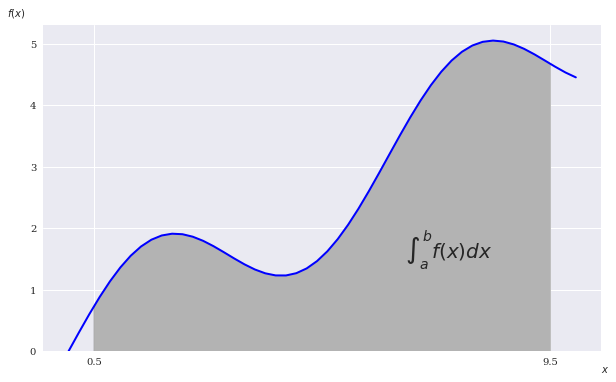

In [83]:
fig, ax = plt.subplots(figsize=(10,6))
plt.plot(x, y, 'b', linewidth=2)
plt.ylim(bottom=0)
Ix = np.linspace(a, b)
Iy = f(Ix)
verts = [(a, 0)] + list(zip(Ix, Iy)) + [(b, 0)]
poly = Polygon(verts, facecolor='0.7', edgecolor='0.5')
ax.add_patch(poly)
plt.text(0.75 * (a + b), 1.5, r"$\int_a^b f(x)dx$", horizontalalignment='center', fontsize=20)
plt.figtext(0.9, 0.075, '$x$')
plt.figtext(0.075, 0.9, '$f(x)$')
ax.set_xticks((a, b))

## Numerical Integration
The scipy.integrate subpackage contains a selection of functions to numerically integrate a given mathematical function for upper and lower integration limits. Examples are sci.fixed_quad() for *fixed Gaussian quadrature*, sci.quad() for *adaptive quadrature*, and sci.romberg() for *Romberg integration*:

In [84]:
sci.fixed_quad(f, a, b)[0]

24.366995967084602

In [85]:
sci.quad(f, a, b)[0]

24.374754718086752

In [86]:
sci.romberg(f, a, b)

24.374754718086713

There are also a number of integration functions that take as input list or ndarray objects with function values and input values, respectively. Examples in this regard are sci.trapz(), using the *trapezoidal* rule, and sci.simps(), implementing *Simpson's* rule:

In [87]:
xi = np.linspace(0.5, 9.5, 25)

In [88]:
sci.trapz(f(xi), xi)

24.352733271544516

In [89]:
sci.simps(f(xi), xi)

24.37496418455075

## Integration by Simulation
The valuation of options and derivatives by Monte Carlo simulation (see Chapter 12) rests on the insight that one can evaluate an integral by simulation. To this end, draw *I* random values of x between the integral limits and evaluate the integration function at every random value for x. Sum up all the function values and take the average to arrive at an average function value over the integration interval. Multiply this value by the length of the integration interval to derive an estimate for the integral value.

The following code shows how the Monte Carlo estimated integral value converges - although not monotonically - to the real one when one increases the number of random draws. The estimator is already quite close for relatively small numbers of random draws:

In [90]:
for i in range(1, 20):
    np.random.seed(1000)
    x = np.random.random(i * 10) * (b - a) + a
    print(np.mean(f(x)) * (b - a))

24.804762279331463
26.522918898332378
26.265547519223976
26.02770339943824
24.99954181440844
23.881810141621663
23.527912274843253
23.507857658961207
23.67236746066989
23.679410416062886
24.424401707879305
24.239005346819056
24.115396924962802
24.424191987566726
23.924933080533783
24.19484212027875
24.117348378249833
24.100690929662274
23.76905109847816


## Symbolic Computation
The previous sections are mainly concerned with numerical computation. This section introduces *symbolic* computation, which can be applied beneficially in many areas of finance. To this end, SymPy, a library specifically dedicated to symbolic computation, is generally used.

### Basics
SymPy introduces new classes of objects. A fundamental class is the Symbol class:

In [91]:
import sympy as sy

In [92]:
x = sy.Symbol('x')
y = sy.Symbol('y')

In [93]:
type(x)

sympy.core.symbol.Symbol

In [94]:
sy.sqrt(x)

sqrt(x)

In [95]:
3 + sy.sqrt(x) - 4 ** 2

sqrt(x) - 13

In [96]:
f = x ** 2 + 3 + 0.5 * x ** 2 + 3 / 2

In [97]:
sy.simplify(f)

1.5*x**2 + 4.5

This example illustrates a major difference to regular python code. Although x has no numerical value, the square root of x is defined with SymPy since x is a Symbol object. In that sense, sy.sqrt(x) can be part of arbitrary mathematical expressions. Similarly, one can define arbitrary functions using Symbol objects. They are not to be confused with Python functions. 

SymPy provides three basic renderers for mathematical expressions:

- LaTeX-based
- Unicode-based
- ASCII-based

When working, for example, solely in a Jupyter Notebook environment (HTML-based), LaTeX rendering is generally a good (i.e., visually appealing) choice. The code that follows sticks to the simplest option, ASCII, to illustrate that there is no manual typesetting involved

In [98]:
sy.init_printing(pretty_print=False, use_unicode=False)

In [99]:
print(sy.pretty(f))

     2      
1.5*x  + 4.5


In [100]:
print(sy.pretty(sy.sqrt(x) + 0.5))

  ___      
\/ x  + 0.5


SymPy also provides many other useful mathematical functions - for example, when it comes to numerically evaluating π. The following example shows the first and final 40 characters of the string representation of π up to the 400,000th digit. It also searches for a six-digit, day-first birthday - a popular task in certain mathematics and IT circles:

In [101]:
%time pi_str = str(sy.N(sy.pi, 400000))

CPU times: user 11.1 s, sys: 188 ms, total: 11.3 s
Wall time: 12.4 s


In [102]:
pi_str[:42]

'3.1415926535897932384626433832795028841971'

In [103]:
pi_str[-40:]

'8245672736856312185020980470362464176199'

In [104]:
%time pi_str.find('061072')

CPU times: user 120 µs, sys: 11 µs, total: 131 µs
Wall time: 147 µs


80847

## Equations
A strength of SymPy is solving equations, e.g. of the form $x^2 - 1 = 0$. SymPy presumes that one is looking for a solution to the equation obtained by equating the given expression to zero. Therefore, equations like $x^2 - 1 = 3$ might have to be reformulated to get the desired result. SymPy can cope with more complex expressions, like $x^3 + 0.5x^2 - 1 = 0$. It can also deal with problems involving imaginary numbers, such as $x^2 + y^2 = 0$:

In [105]:
sy.solve(x ** 2 - 1)

[-1, 1]

In [106]:
sy.solve(x ** 2 - 1 - 3)

[-2, 2]

In [107]:
sy.solve(x ** 3 + 0.5 * x ** 2 - 1)

[0.858094329496553, -0.679047164748276 - 0.839206763026694*I, -0.679047164748276 + 0.839206763026694*I]

In [108]:
sy.solve(x ** 2 + y ** 2)

[{x: -I*y}, {x: I*y}]

## Integration and Differentiation
Another strength of SymPy is integration and differentiation. The example that follows revisits the example function used for numerical- and simulation-based integration and derives both a *symbolically* and *numerically* exact solution. Symbol objects for the integration limits objects are required to get started:

In [109]:
a, b = sy.symbols('a b')

In [110]:
I = sy.Integral(sy.sin(x) + 0.5 * x, (x, a, b))

In [111]:
print(sy.pretty(I))

  b                    
  /                    
 |                     
 |  (0.5*x + sin(x)) dx
 |                     
/                      
a                      


In [112]:
int_func = sy.integrate(sy.sin(x) + 0.5 * x, x)

In [113]:
print(sy.pretty(int_func))

      2         
0.25*x  - cos(x)


In [114]:
Fb = int_func.subs(x, 9.5).evalf()

In [115]:
Fa = int_func.subs(x, 0.5).evalf()

In [116]:
Fb - Fa

24.3747547180867

The integral can also be solved symbolically with the symbolic integration limits:

In [117]:
int_func_limits = sy.integrate(sy.sin(x) + 0.5 * x, (x, a, b))

In [118]:
print(sy.pretty(int_func_limits))

        2         2                  
- 0.25*a  + 0.25*b  + cos(a) - cos(b)


In [119]:
int_func_limits.subs({a: 0.5, b: 9.5}).evalf()

24.3747547180868

## Differentiation
The derivative of the antiderivative yields in general the original function. Applying the sy.diff() function to the symbolic antiderivative illustrates this:

In [120]:
int_func.diff()

0.5*x + sin(x)

As with the integration example, differentiation can be used to derive the exact solution of the convex minimization problem this chapter looked at earlier. To this end, the respective function is defined symbolically, partial derivatives are derived, and the roots are identified.

A necessary but not sufficient condition for a global minimum is that both partial derivatives are zero. However, there is no guarantee of a symbolic solution. Both algorithmic and (multiple) existence issues come into play here. However, one can solve the two first-order conditions numerically, providing "educated" guesses based on the global and local minimization efforts from before:

In [121]:
f = (sy.sin(x) + 0.05 * x ** 2 + sy.sin(y) + 0.05 * y ** 2)

In [122]:
del_x = sy.diff(f, x)
del_x

0.1*x + cos(x)

In [123]:
del_y = sy.diff(f, y)
del_y

0.1*y + cos(y)

In [124]:
xo = sy.nsolve(del_x, -1.5)
xo

-1.42755177876459

In [125]:
yo = sy.nsolve(del_y, -1.5)
yo

-1.42755177876459

In [126]:
f.subs({x : xo, y : yo}).evalf()

-1.77572565314742

In [127]:
xo = sy.nsolve(del_x, 1.5)
xo

1.74632928225285

In [128]:
yo = sy.nsolve(del_y, 1.5)
yo

1.74632928225285

In [129]:
f.subs({x : xo, y : yo}).evalf()

2.27423381055640

This numerically illustrates that the first-order conditions are necessary but not sufficient.

## Conclusions
The mathematical topics and tools covered in this notebook are important to finance and financial analysis. Examples of applications that benefit from approximation include: factor-based models, yield curve interpolation, and regression-based Monte Carlo valuation approaches for American options. Convex optimization techniques help to calibrate parametric option pricing models to market quotes or implied volatilities of options.

Numerical integration is central to the pricing of options and derivatives. Having derived the risk-neutral probability measure for a (set of) stochastic process(es), option pricing boils down to taking the expectation of the option's payoff under the risk-neutral measure and discounting this value back to the present date. Chapter 12 will cover simulation of different stochastic processes under the risk-neutral measure.

At the end of the chapter, SymPy was introduced. This library can help as an efficient tool for solving equations, integrating data and differentiating data. Alongside other algorithmic tooling and processes, this is quite useful.
